In [152]:
# Librairies :
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller , kpss 
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import het_arch
from statsmodels.stats.diagnostic import acorr_ljungbox
from arch import arch_model # a installé manuellement (pip install arch)
from arch.univariate import ARX, GARCH, StudentsT
from scipy.stats import jarque_bera, skew, kurtosis , t







In [153]:
# Première étape : importation et néttoyage des variables (Typage/Valeur manquantes/Alignement temporel/Suppression du surplus)

df_micron = pd.read_excel("Projet Économétrique.xlsx", sheet_name = "Micron") # on définit la variable au fichier xlsx via panda (df = DataFrame)
df_micron = df_micron[['Date','Dernier']] # On ne garde que la date et le prix (on élimine le surplus)
df_micron.rename(columns={'Dernier':'Price_MU'},inplace=True) # On rename la colonne Dernier (inplace évite de dupliquer inutilement donc économie de mémoire)
df_micron.set_index('Date',inplace=True) # Permet de définir cette colonne en index officiel du DataFrame 

df_sox = pd.read_excel("Projet Économétrique.xlsx", sheet_name = "SOX Index") 
df_sox = df_sox[['Date','Dernier']] 
df_sox.rename(columns={'Dernier':'Price_SOX'},inplace=True)
df_sox.set_index('Date',inplace=True)

df_nvidia = pd.read_excel("Projet Économétrique.xlsx", sheet_name = "NVIDIA")
df_nvidia = df_nvidia[['Date','Dernier']]
df_nvidia.rename(columns={'Dernier':'Price_NVIDIA'},inplace=True)
df_nvidia.set_index('Date',inplace=True)

df_fx = pd.read_excel("Projet Économétrique.xlsx", sheet_name = "USDKRW")
df_fx = df_fx[['Date','Dernier']]
df_fx.rename(columns={'Dernier':'USD_KRW'},inplace=True)
df_fx.set_index('Date',inplace=True)

df_vix = pd.read_excel("Projet Économétrique.xlsx", sheet_name="VIX")
df_vix = df_vix[['Date','Dernier']]
df_vix.rename(columns={'Dernier':'VIX'},inplace=True)
df_vix.set_index("Date",inplace=True)

# df_micron.info() # pour déterminer la nature de chaque données
# df_micron.head() # Permet de lire un échantillon de la variable, on peut modifier head(10) pour les 10 premiers (par défaut 5)

In [154]:
# Alignement temporel 

df_final = pd.concat([df_micron , df_sox , df_nvidia , df_fx , df_vix], axis=1 , join='outer', sort=False) # Concaténation des DataFrames, 
# axis=1 pour fusion horizontale
# join='outer' pour vérifier si une variable no possède pas de cotation à chaque date t
# sort=False pour désactiver le tri implicite de panda (lourd en ressoource)

df_final.sort_index(inplace=True) # On ordonne les valeurs temporel 

df_final.isnull().sum() # On regarde combien de NaN (Not a Number) (donc combien de dates ne sont pas cotés)

# Traitement des valeurs manquantes 
# Méthode choisie : suppression des NaN (+ de précision, représente que 4% de l'échantillon)

df_final.dropna(inplace=True) # Élimine toute ligne t contenant un NaN sur l'une des variables

df_final.shape # Donne la taille de la matrice finale 

# Nettoyage terminé.

(2553, 5)

In [155]:
# Convertion des prix en rendements logarithmes pour stationnariser (Utilisation de numpy ici pour ln)

# df_final['Price_MU'] -> Pt 
# df_final['Price_MU'].shift(1) -> Pt -1 

# Rt = ln(Pt / Pt-1) = ln(Pt) - ln(Pt-1)

df_final['rt_mu'] = np.log(df_final['Price_MU']) - np.log(df_final['Price_MU'].shift(1)) # On définit dans df_final un vecteur des rendements pour mu
df_final['rt_sox'] = np.log(df_final['Price_SOX']) - np.log(df_final['Price_SOX'].shift(1))
df_final['rt_nvidia'] = np.log(df_final['Price_NVIDIA']) - np.log(df_final['Price_NVIDIA'].shift(1))
df_final['rt_fx'] = np.log(df_final['USD_KRW']) - np.log(df_final['USD_KRW'].shift(1))
df_final['d_vix'] = df_final['VIX'] - df_final['VIX'].shift(1) # Ici différenciation simple 

df_final.dropna(inplace=True) # On supprime la première ligne de NaN 

df_final.head()

,Price_MU,Price_SOX,Price_NVIDIA,USD_KRW,VIX,rt_mu,rt_sox,rt_nvidia,rt_fx,d_vix
Date,,,,,,,,,,
2016-01-05,14.82,649.5,0.82,1189.81,19.34,0.033622,-0.010415,0.012270,0.000387,-1.36
2016-01-06,14.22,631.2,0.79,1199.52,20.59,-0.041328,-0.028580,-0.037271,0.008128,1.25
2016-01-07,13.66,610.2,0.76,1196.29,24.99,-0.040178,-0.033836,-0.038715,-0.002696,4.40
2016-01-08,13.33,600.5,0.74,1206.94,27.01,-0.024455,-0.016024,-0.026668,0.008863,2.02
2016-01-11,12.53,603.5,0.74,1203.76,24.30,-0.061891,0.004983,0.000000,-0.002638,-2.71


In [156]:
# Test Augmented Dickey-Fuller (Utilisation de statsmodels ici)

variables = ['rt_mu','rt_sox','rt_nvidia','rt_fx','d_vix']

print("--- Tests ADF (H0: Non-Stationnaire) ---")
for var in variables:
    pval_adf = adfuller(df_final[var])[1] # Le 1 désigne le 2 ème élément de sortie de adfuller 
    print(f"{var} : p-value = {pval_adf}") # f permet d'implémenter de manière plus simple/lisible les variables

# Test kpss

print("\n --- Tests kpss (H0: Stationnaire) ---")
for var in variables:
    pval_kpss = kpss(df_final[var])[1]
    print(f"{var} : p-value = {pval_kpss}") 

# Utilisation de deux tests afin d'augmenter la robustesse via des angles opposés.

--- Tests ADF (H0: Non-Stationnaire) ---
rt_mu : p-value = 7.630005801247457e-28
rt_sox : p-value = 2.3682736666951642e-27
rt_nvidia : p-value = 2.48015690696638e-30
rt_fx : p-value = 0.0
d_vix : p-value = 2.1878827481853448e-30

 --- Tests kpss (H0: Stationnaire) ---
rt_mu : p-value = 0.1
rt_sox : p-value = 0.1
rt_nvidia : p-value = 0.1
rt_fx : p-value = 0.1
d_vix : p-value = 0.1


C:\Users\mateo\AppData\Local\Temp\ipykernel_6296\604249518.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  pval_kpss = kpss(df_final[var])[1]
C:\Users\mateo\AppData\Local\Temp\ipykernel_6296\604249518.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  pval_kpss = kpss(df_final[var])[1]
C:\Users\mateo\AppData\Local\Temp\ipykernel_6296\604249518.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  pval_kpss = kpss(df_final[var])[1]
C:\Users\mateo\AppData\Local\Temp\ipykernel_6296\604249518.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-va

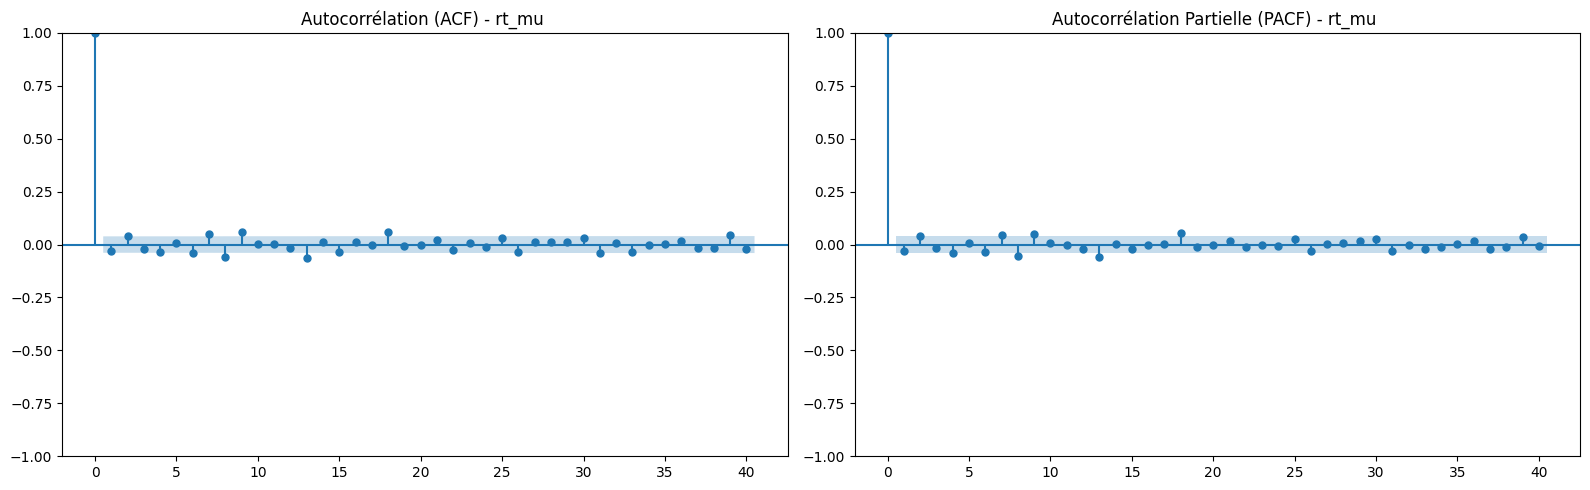

In [157]:
# Identification du modèle ARMA(p,q) via ACF & PACF (avant d'extraire les résidus pour un modèle GARCH)

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(16,5)) # On définit la zone des graphiques

plot_acf(df_final['rt_mu'], ax=ax1, lags=40, title="Autocorrélation (ACF) - rt_mu ") 
plot_pacf(df_final['rt_mu'], ax=ax2, lags=40, title="Autocorrélation Partielle (PACF) - rt_mu ")

plt.tight_layout() # Mieux visuellement 
plt.show() 

# On observe aucun retard significatif donc modèle de type ARMA(0,0) (bruit blanc faible)

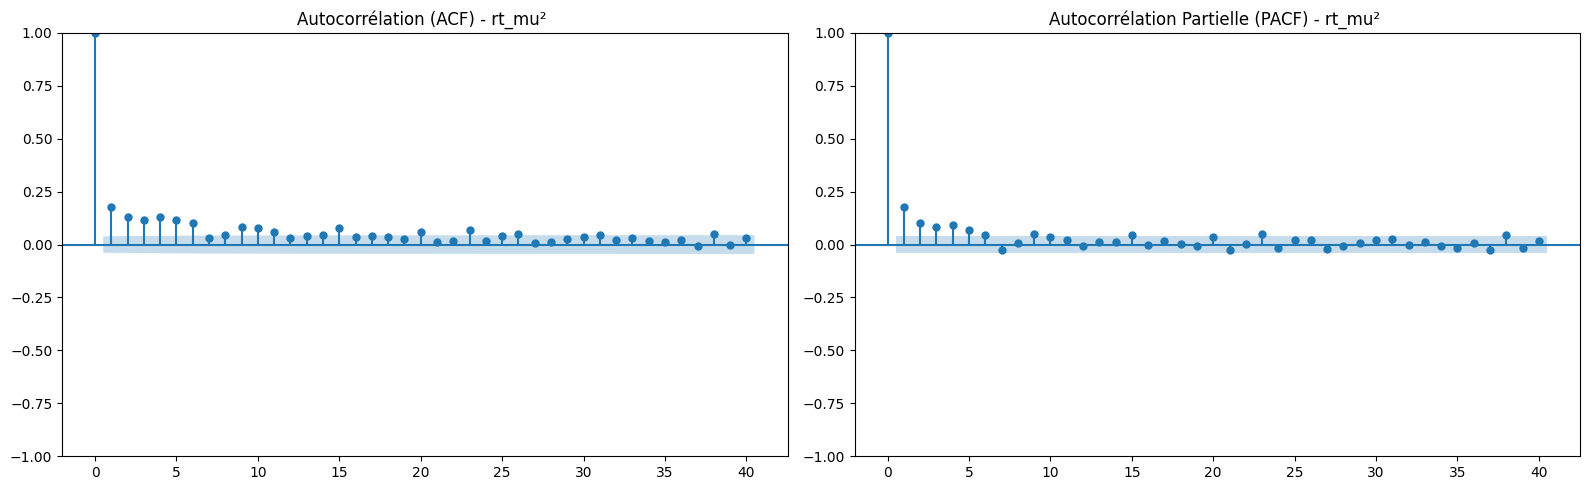

In [158]:
# Tests des effets ARCH (hétéroscédasticité conditionnelle) pour analyser visuellement la volatilité

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(16,5))

plot_acf(df_final['rt_mu']**2,ax=ax1,lags=40,title="Autocorrélation (ACF) - rt_mu² ")

plot_pacf(df_final['rt_mu']**2,ax=ax2,lags=40,title="Autocorrélation Partielle (PACF) - rt_mu² ")

plt.tight_layout()
plt.show()


In [159]:
# Test d'Engle (ARCH-LM) (hétéroscédasticité conditionnelle) pour analyser statistiquement la volatilité avant modélisation d'un modèle GARCH

residus_rt_mu = df_final['rt_mu'] - df_final['rt_mu'].mean() # mean renvoie la moyenne empirique, ici on isole les résidus du ARMA(0,0)

stat_lm, pval_lm, _ , _ = het_arch(residus_rt_mu, nlags=5) # on assigne à la sortie de het_arch les 4 variables 
# nlags = 5 pour les 5 jours de la semaine (ddl)
# stat_lm = multiplicateur de lagrange (LM = T x R²)
# pval_lm = p-value du test LM 

print("--- Test ARCH-LM d'Engle ---")
print(f"Statistique du test (LM) : {stat_lm}") # TODO: Ajouter ici et dans les print des résultats de test des if pour comparer avec la valeur de la table ?
print(f"p-value (LM : {pval_lm})")

# Rejet de H0 donc : On observe ici une forte hétéroscédasticité conditionnelle -> Obligation utilisation modèle GARCH
# /!\ Dans GARCH p = Le nombre de retard de la variance passée / q = le nombre de retard des chocs passés au carré
# Rappel : Dans ARMA p = Nombre de retard de la série elle même / q = le nombre de retard des erreurs


--- Test ARCH-LM d'Engle ---
Statistique du test (LM) : 154.99332492847986
p-value (LM : 1.154234454252436e-31)


In [160]:
# Estimation du modèle GARCH

df_final['rt_mu_pct'] = df_final['rt_mu']*100 # Rescaling pour avoir une variance entre 1 et 1000 

modele_garch = arch_model(df_final['rt_mu_pct'], mean='Constant', vol='Garch', p=1, q=1)
# /!\ En Python on inverse GARCH(q,p)
# arch_model initialise le cadre de modélisation de la volatilité 
# mean='Constant'définit la structure de la moyenne (<=> ARMA(0,0))
# vol='Garch' définit la famille du modèle de variance 


resultats_garch = modele_garch.fit(disp='off')
# .fit calcule les valeurs numériques optimales des paramètres 
# disp='off' désactive l'affichage ligne par ligne (plus lisible)

print(resultats_garch.summary())

# TODO: Potentiellement écrire l'équation de régression après obtention des résultats 


                     Constant Mean - GARCH Model Results                      
Dep. Variable:              rt_mu_pct   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -6365.74
Distribution:                  Normal   AIC:                           12739.5
Method:            Maximum Likelihood   BIC:                           12762.9
                                        No. Observations:                 2552
Date:                Wed, Apr 01 2026   Df Residuals:                     2551
Time:                        12:47:50   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.1534  5.487e-02      2.795  5.184e-03 [4.584e-0

In [161]:
# Estimation du modèle GARCH-X (avec variables exogènes)

df_final[['rt_sox_pct' , 'rt_nvidia_pct' , 'rt_fx_pct']] = df_final[['rt_sox' , 'rt_nvidia' , 'rt_fx']]*100 # Rescaling pour aligner rt_mu avec le reste (mais pas vix car déjà %)

X_exog = df_final[['rt_sox_pct' , 'rt_nvidia_pct' , 'rt_fx_pct' , 'd_vix']]

modele_garch_x = arch_model(df_final['rt_mu_pct'], x=X_exog , mean='LS' , vol='Garch' , p=1 , q=1 )

resultats_garch_x = modele_garch_x.fit(disp='off')
print(resultats_garch_x.summary())

# TODO: Parler de l'interprétation des résultats (ex: alpha1+beta1 = 0.989 donc mémoire longue)

                     Least Squares - GARCH Model Results                      
Dep. Variable:              rt_mu_pct   R-squared:                       0.611
Mean Model:             Least Squares   Adj. R-squared:                  0.610
Vol Model:                      GARCH   Log-Likelihood:               -5234.23
Distribution:                  Normal   AIC:                           10484.5
Method:            Maximum Likelihood   BIC:                           10531.2
                                        No. Observations:                 2552
Date:                Wed, Apr 01 2026   Df Residuals:                     2547
Time:                        12:47:50   Df Model:                            5
                                   Mean Model                                   
                    coef    std err          t      P>|t|       95.0% Conf. Int.
--------------------------------------------------------------------------------
Const             0.0186  3.757e-02      0.495

In [162]:
# Modèle GARCH-X Restreint ( Exclusions fx et VIX et constante car non significatives au vu des résultats précédents )

X_final = df_final[['rt_sox_pct' , 'rt_nvidia_pct']]

modele_final = ARX(df_final['rt_mu_pct'], x=X_final , lags=0 , constant=False)
# Passage ARX (c'est la fonction complète pour faire simple, pour pouvoir retirer la constant) mais obligation de diviser en deux avec volatilité 

modele_final.volatility = GARCH(p=1, q=1) # On définit la partie volatilité du modèle ARX

resultats_garch_x = modele_final.fit(disp='off')
print(resultats_garch_x.summary())

# TODO: écrire l'équation de régression finale après interprétation des résultats blablabla 

# On observe une diminution des critères d'AIC et BIC donc amélioration du modèle

                          AR-X - GARCH Model Results                          
Dep. Variable:              rt_mu_pct   R-squared:                       0.611
Mean Model:                      AR-X   Adj. R-squared:                  0.611
Vol Model:                      GARCH   Log-Likelihood:               -5236.19
Distribution:                  Normal   AIC:                           10482.4
Method:            Maximum Likelihood   BIC:                           10511.6
                                        No. Observations:                 2552
Date:                Wed, Apr 01 2026   Df Residuals:                     2550
Time:                        12:47:51   Df Model:                            2
                                  Mean Model                                  
                    coef    std err          t      P>|t|     95.0% Conf. Int.
------------------------------------------------------------------------------
rt_sox_pct        1.2427  3.494e-02     35.571 3.884

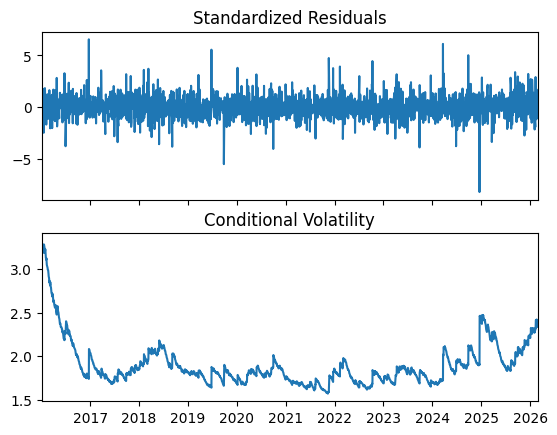

In [163]:
# Analyse des résidus standardisés (zt) pour valider notre modèle GARCH-X final 

fig = resultats_garch_x.plot()
plt.show()

# Graphique du bas correspond au risque de Micron en point de pourcentage 

In [164]:
# Validation numérique (Tests statistiques sur les résidus standardisés)

z_t = resultats_garch_x.std_resid # On extrait les résidus standardisés du modèle GARCH-X final pour les analyser numériquement

lb_test = acorr_ljungbox(z_t, lags=[10], return_df=True) # Test de Ljung-Box pour vérifier l'absence d'autocorrélation des résidus standardisés
arch_lm_test = resultats_garch_x.arch_lm_test(lags=10) # Test d'Engle pour vérifier l'absence d'effets ARCH dans les résidus standardisés
jb_stat, jb_pvalue = jarque_bera(z_t) # Test de Jarque-Bera pour vérifier la normalité des résidus standardisés

sk = skew(z_t)
ku = kurtosis(z_t, fisher=False)

print("--- RÉSULTATS DES TESTS DE VALIDATION ---")
print(f"Ljung-Box (Moyenne) p-value     : {lb_test['lb_pvalue'].values[0]:.4f}")
print(f"ARCH-LM (Variance) p-value      : {arch_lm_test.pval:.4f}")
print(f"Jarque-Bera (Normalité) p-value : {jb_pvalue:.4f}")
print("-" * 41)
print(f"Skewness (Asymétrie)            : {sk:.4f}")
print(f"Kurtosis (Aplatissement)        : {ku:.4f}")

# TODO: Interprétation combiné avec if dans les print 
# Ljung-Box Non Rejet H0 / les 2 autres Rejet H0 

--- RÉSULTATS DES TESTS DE VALIDATION ---
Ljung-Box (Moyenne) p-value     : 0.0609
ARCH-LM (Variance) p-value      : 0.0017
Jarque-Bera (Normalité) p-value : 0.0000
-----------------------------------------
Skewness (Asymétrie)            : 0.2176
Kurtosis (Aplatissement)        : 7.9260


In [165]:
# Passage d'une loi normale à une loi de Student pour mieux capturer les queues épaisses (évènements extrêmes)

modele_final_t = ARX(df_final['rt_mu_pct'], x=X_final , lags=0 , constant=False)
modele_final_t.volatility = GARCH(p=1, q=1)
modele_final_t.distribution = StudentsT() # On change la distribution des résidus du modèle de base (normale) à une loi de Student pour mieux capturer les queues épaisses
resultats_garch_t = modele_final_t.fit(disp='off')
print(resultats_garch_t.summary())

# Amélioration du BIC et de l'AIC donc meilleure performance du modèle avec loi de Student (meilleure capture des évènements extrêmes)

                             AR-X - GARCH Model Results                             
Dep. Variable:                    rt_mu_pct   R-squared:                       0.608
Mean Model:                            AR-X   Adj. R-squared:                  0.608
Vol Model:                            GARCH   Log-Likelihood:               -5085.22
Distribution:      Standardized Student's t   AIC:                           10182.4
Method:                  Maximum Likelihood   BIC:                           10217.5
                                              No. Observations:                 2552
Date:                      Wed, Apr 01 2026   Df Residuals:                     2550
Time:                              12:47:51   Df Model:                            2
                                  Mean Model                                  
                    coef    std err          t      P>|t|     95.0% Conf. Int.
-----------------------------------------------------------------------------

In [166]:
# Extraction des nouveaux résidus standardisés pour valider le modèle avec loi de Student 

z_t_student = resultats_garch_t.std_resid

lb_test_t = acorr_ljungbox(z_t_student, lags=[10], return_df=True)
arch_lm_test_t = resultats_garch_t.arch_lm_test(lags=10)
# Pas de Jacque-Bera ici car la distribution des résidus n'est plus normale (loi de Student)

print("--- VALIDATION DU MODÈLE STUDENT ---")
print(f"Ljung-Box (Moyenne) p-value : {lb_test_t['lb_pvalue'].values[0]:.4f}")
print(f"ARCH-LM (Variance) p-value  : {arch_lm_test_t.pval:.4f}")

# Problème des queues épaisses (Kurtosis) mais la variance reste mal spécifiée

# Solution, modèle GJR-GARCH pour capturer l'asymétrie des chocs positifs et négatifs (leverage effect)

--- VALIDATION DU MODÈLE STUDENT ---
Ljung-Box (Moyenne) p-value : 0.0650
ARCH-LM (Variance) p-value  : 0.0009


In [167]:
# Modèle GJR-GARCH (Glosten-Jagannathan-Runkle) 
# Ici on introduit une variable indicatrice qui prend la valeur 1 si le choc est négatif (rt_mu_pct < 0) et 0 sinon, pour capturer l'asymétrie des chocs sur la volatilité (leverage effect)

modele_gjr = ARX(df_final['rt_mu_pct'], x=X_final , lags=0 , constant=False) # On définit la moyenne (inchangée)
modele_gjr.volatility = GARCH(p=1, o=1, q=1) # On ajoute o=1 pour les chocs négatifs 
modele_gjr.distribution = StudentsT() # On garde la loi de Student pour les résidus pour mieux capturer les évènements extrêmes

res_gjr = modele_gjr.fit(disp='off') # Estimation du modèle GJR-GARCH
print(res_gjr.summary()) 

print("--- MODÈLE GJR-GARCH ---")

z_t_gjr = res_gjr.std_resid

lb_test_gjr = acorr_ljungbox(z_t_gjr, lags=[10], return_df=True)
arch_lm_test_gjr = res_gjr.arch_lm_test(lags=10)

print("\n--- VALIDATION DU MODÈLE GJR-GARCH(1,1,1) ---")
print(f"Ljung-Box (Moyenne) p-value : {lb_test_gjr['lb_pvalue'].values[0]:.4f}")
print(f"ARCH-LM (Variance) p-value  : {arch_lm_test_gjr.pval:.4f}")

# Modèle GJR-GARCH est rejeté.
# Le paramètre d'asymétrie n'est pas significatif et Le critère AIC se dégrade 

# Le modèle final retenu est le ARX-GARCH(1,1) avec distribution de Student pas parfait mais robuste et justifié.


                           AR-X - GJR-GARCH Model Results                           
Dep. Variable:                    rt_mu_pct   R-squared:                       0.608
Mean Model:                            AR-X   Adj. R-squared:                  0.608
Vol Model:                        GJR-GARCH   Log-Likelihood:               -5085.01
Distribution:      Standardized Student's t   AIC:                           10184.0
Method:                  Maximum Likelihood   BIC:                           10224.9
                                              No. Observations:                 2552
Date:                      Wed, Apr 01 2026   Df Residuals:                     2550
Time:                              12:47:51   Df Model:                            2
                                  Mean Model                                  
                    coef    std err          t      P>|t|     95.0% Conf. Int.
-----------------------------------------------------------------------------

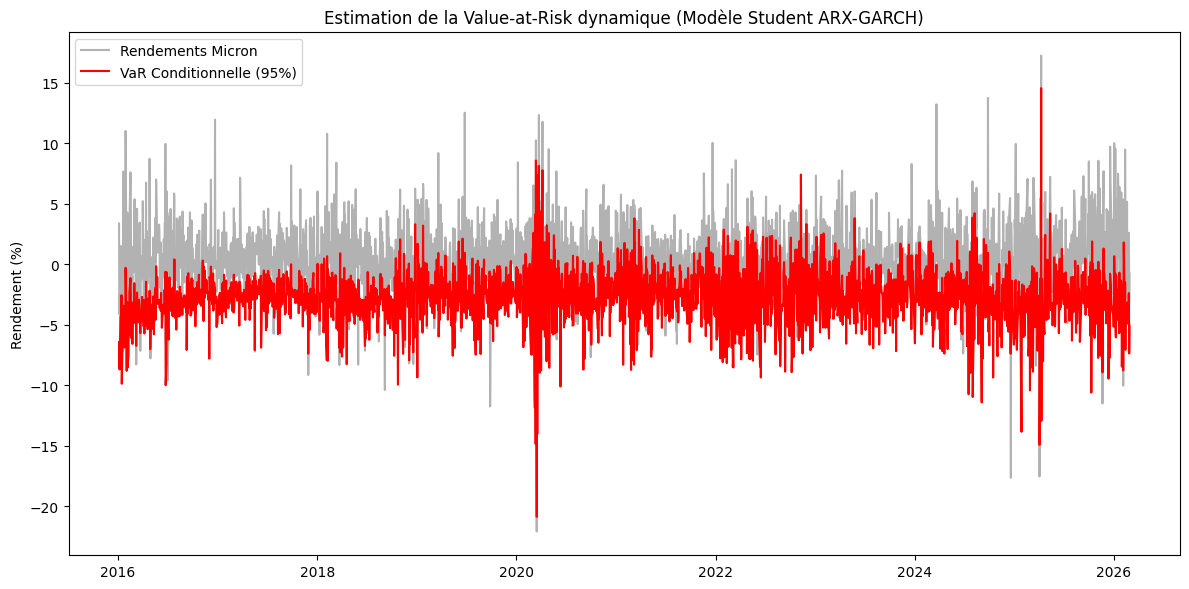

In [172]:
# Estimation de la Value-at-Risk dynamique (VaR) à partir du modèle ARX-GARCH(1,1) avec loi de Student

alpha = 0.05

mu_t = df_final['rt_mu_pct'] - resultats_garch_t.resid
sigma_t = resultats_garch_t.conditional_volatility

nu= resultats_garch_t.params['nu']

q_alpha = t.ppf(alpha, df=nu) * np.sqrt((nu - 2) / nu)

VaR_95 = mu_t + sigma_t * q_alpha

plt.figure(figsize=(12, 6))
plt.plot(df_final.index, df_final['rt_mu_pct'], label="Rendements Micron", color='grey', alpha=0.6)
plt.plot(df_final.index, VaR_95, label="VaR Conditionnelle (95%)", color='red', linewidth=1.5)
plt.title("Estimation de la Value-at-Risk dynamique (Modèle Student ARX-GARCH)")
plt.ylabel("Rendement (%)")
plt.legend()
plt.tight_layout()
plt.show()